In [20]:
import datetime
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

In [ ]:
!wget 

In [21]:
data = pd.read_csv('Preprocessed/Preprocessed_data.csv')
data.head()

,Date,Comp,Day,Venue,Result,Team,Opponent,xG,xGA,Poss,...,O_Fld.2,O_Off.1,O_Crs.1,O_Int.1,O_TklW.1,O_PKwon,O_PKcon,O_OG,O_Lost.1,MatchID
0,2017-08-12,Premier League,Sat,Away,W,Manchester City,Brighton,1.9,0.3,77.0,...,8.0,6.0,8.0,12.0,8.0,0.0,0.0,1.0,13.0,#PerthWestern United
1,2017-08-21,Premier League,Mon,Home,D,Manchester City,Everton,1.1,0.6,64.0,...,7.0,3.0,9.0,16.0,12.0,0.0,0.0,0.0,22.0,#Melb VictoryWestern United
2,2017-08-26,Premier League,Sat,Away,W,Manchester City,Bournemouth,1.4,0.5,70.0,...,14.0,0.0,9.0,12.0,13.0,0.0,0.0,0.0,23.0,#Melb CityWestern United
3,2017-09-09,Premier League,Sat,Home,W,Manchester City,Liverpool,2.4,0.7,66.0,...,10.0,2.0,9.0,18.0,12.0,0.0,0.0,0.0,9.0,#Wellington Phoenix FCWestern United
4,2017-09-13,Champions Lg,Wed,Away,W,Manchester City,nl Feyenoord,1.3,0.3,71.0,...,9.0,3.0,8.0,13.0,9.0,0.0,0.0,0.0,14.0,#BrisbaneWestern United


In [22]:
for index, row in data.iterrows():
    if row['Venue'] == 'Home' and row['Result'] == 'W':
        data.loc[index, 'Result'] = 'H'
    elif row['Venue'] == 'Home' and row['Result'] == 'L':
        data.loc[index, 'Result'] = 'A'
    elif row['Venue'] == 'Away' and row['Result'] == 'W':
        data.loc[index, 'Result'] = 'A'
    elif row['Venue'] == 'Away' and row['Result'] == 'L':
        data.loc[index, 'Result'] = 'H'
    else:
        data.loc[index, 'Result'] = 'D'
        

In [23]:
data.Result.value_counts()

Result
H    14264
A    10092
D     8181
Name: count, dtype: int64

In [24]:
data.head()

,Date,Comp,Day,Venue,Result,Team,Opponent,xG,xGA,Poss,...,O_Fld.2,O_Off.1,O_Crs.1,O_Int.1,O_TklW.1,O_PKwon,O_PKcon,O_OG,O_Lost.1,MatchID
0,2017-08-12,Premier League,Sat,Away,A,Manchester City,Brighton,1.9,0.3,77.0,...,8.0,6.0,8.0,12.0,8.0,0.0,0.0,1.0,13.0,#PerthWestern United
1,2017-08-21,Premier League,Mon,Home,D,Manchester City,Everton,1.1,0.6,64.0,...,7.0,3.0,9.0,16.0,12.0,0.0,0.0,0.0,22.0,#Melb VictoryWestern United
2,2017-08-26,Premier League,Sat,Away,A,Manchester City,Bournemouth,1.4,0.5,70.0,...,14.0,0.0,9.0,12.0,13.0,0.0,0.0,0.0,23.0,#Melb CityWestern United
3,2017-09-09,Premier League,Sat,Home,H,Manchester City,Liverpool,2.4,0.7,66.0,...,10.0,2.0,9.0,18.0,12.0,0.0,0.0,0.0,9.0,#Wellington Phoenix FCWestern United
4,2017-09-13,Champions Lg,Wed,Away,A,Manchester City,nl Feyenoord,1.3,0.3,71.0,...,9.0,3.0,8.0,13.0,9.0,0.0,0.0,0.0,14.0,#BrisbaneWestern United


In [5]:
# def ForFutureMatches(data):
#     data = pd.get_dummies(data, columns=[
#                           'Venue', 'Day', 'Team', 'Opponent', 'Captain', 'Formation', 'Referee', 'Comp'], dtype=int)
#     data['FTR'] = np.where(data['Result'] == 'W', 1, np.where(
#         data['Result'] == 'D', 0, np.where(data['Result'] == 'L', 2, np.nan)))
#     data.drop('Result', axis=1, inplace=True)
#     data['weight'] = 1
#     return data

In [25]:
data['FTR'] = np.where(data['Result'] == 'H', 0, np.where(

    data['Result'] == 'D', 1, np.where(data['Result'] == 'A', 2, np.nan)))

data.drop('Result', axis=1, inplace=True)

In [26]:
data.FTR.value_counts()

FTR
0.0    14264
2.0    10092
1.0     8181
Name: count, dtype: int64

In [27]:
data['Date'] = pd.to_datetime(data['Date'])


def get_weights(data):
    now = datetime.datetime.now()
    weight = 1.0 / (1 + (now - data['Date']).dt.days / 365)
    return weight


data['weight'] = get_weights(data)
data.head()

,Date,Comp,Day,Venue,Team,Opponent,xG,xGA,Poss,Attendance,...,O_Crs.1,O_Int.1,O_TklW.1,O_PKwon,O_PKcon,O_OG,O_Lost.1,MatchID,FTR,weight
0,2017-08-12,Premier League,Sat,Away,Manchester City,Brighton,1.9,0.3,77.0,30415.0,...,8.0,12.0,8.0,0.0,0.0,1.0,13.0,#PerthWestern United,2.0,0.131532
1,2017-08-21,Premier League,Mon,Home,Manchester City,Everton,1.1,0.6,64.0,49108.0,...,9.0,16.0,12.0,0.0,0.0,0.0,22.0,#Melb VictoryWestern United,1.0,0.131960
2,2017-08-26,Premier League,Sat,Away,Manchester City,Bournemouth,1.4,0.5,70.0,10419.0,...,9.0,12.0,13.0,0.0,0.0,0.0,23.0,#Melb CityWestern United,2.0,0.132198
3,2017-09-09,Premier League,Sat,Home,Manchester City,Liverpool,2.4,0.7,66.0,54172.0,...,9.0,18.0,12.0,0.0,0.0,0.0,9.0,#Wellington Phoenix FCWestern United,0.0,0.132872
4,2017-09-13,Champions Lg,Wed,Away,Manchester City,nl Feyenoord,1.3,0.3,71.0,43500.0,...,8.0,13.0,9.0,0.0,0.0,0.0,14.0,#BrisbaneWestern United,2.0,0.133066


In [31]:
data_mr = data[['Venue', 'Team', 'Opponent',
                'Formation', 'Comp', 'FTR', 'weight', 'MatchID']]
data.drop(['Venue', 'Day', 'Team', 'Opponent',
           'Captain', 'Formation', 'Referee', 'Comp', 'MatchID', 'FTR', 'weight'], axis=1, inplace=True)

In [34]:
data.head()

,Date,xG,xGA,Poss,Attendance,SoT,G/Sh,G/SoT,Dist,PK,...,O_Fls,O_Fld.2,O_Off.1,O_Crs.1,O_Int.1,O_TklW.1,O_PKwon,O_PKcon,O_OG,O_Lost.1
0,2017-08-12,1.9,0.3,77.0,30415.0,4.0,0.07,0.25,19.5,0.0,...,6.0,8.0,6.0,8.0,12.0,8.0,0.0,0.0,1.0,13.0
1,2017-08-21,1.1,0.6,64.0,49108.0,6.0,0.05,0.17,20.0,0.0,...,9.0,7.0,3.0,9.0,16.0,12.0,0.0,0.0,0.0,22.0
2,2017-08-26,1.4,0.5,70.0,10419.0,8.0,0.11,0.25,16.2,0.0,...,13.0,14.0,0.0,9.0,12.0,13.0,0.0,0.0,0.0,23.0
3,2017-09-09,2.4,0.7,66.0,54172.0,10.0,0.38,0.50,14.0,0.0,...,9.0,10.0,2.0,9.0,18.0,12.0,0.0,0.0,0.0,9.0
4,2017-09-13,1.3,0.3,71.0,43500.0,7.0,0.36,0.57,14.4,0.0,...,14.0,9.0,3.0,8.0,13.0,9.0,0.0,0.0,0.0,14.0


In [37]:
means = data.mean()
data.fillna(means, inplace=True)
# data.dropna(inplace=True)

ss = MinMaxScaler()
data.iloc[:,1:] = ss.fit_transform(data.iloc[:,1:])

In [39]:
df = pd.concat([data, data_mr], axis=1)
df.shape

(32537, 159)

In [41]:
df.head()

,Date,xG,xGA,Poss,Attendance,SoT,G/Sh,G/SoT,Dist,PK,...,Day,Team,Opponent,Captain,Formation,Referee,Comp,MatchID,FTR,weight
0,2017-08-12,0.208791,0.050000,0.876923,0.168261,0.181818,0.07,0.25,0.383812,0.0,...,Sat,Manchester City,Brighton,Vincent Kompany,3-1-4-2,Michael Oliver,Premier League,#PerthWestern United,2.0,0.131532
1,2017-08-21,0.120879,0.100000,0.676923,0.271710,0.272727,0.05,0.17,0.396867,0.0,...,Mon,Manchester City,Everton,Vincent Kompany,3-1-4-2,Robert Madley,Premier League,#Melb VictoryWestern United,1.0,0.131960
2,2017-08-26,0.153846,0.083333,0.769231,0.057600,0.363636,0.11,0.25,0.297650,0.0,...,Sat,Manchester City,Bournemouth,Vincent Kompany,4-3-3,Mike Dean,Premier League,#Melb CityWestern United,2.0,0.132198
3,2017-09-09,0.263736,0.116667,0.707692,0.299735,0.454545,0.38,0.50,0.240209,0.0,...,Sat,Manchester City,Liverpool,David Silva,3-1-4-2,Jonathan Moss,Premier League,#Wellington Phoenix FCWestern United,0.0,0.132872
4,2017-09-13,0.142857,0.050000,0.784615,0.240675,0.318182,0.36,0.57,0.250653,0.0,...,Wed,Manchester City,nl Feyenoord,David Silva,4-3-3,Szymon Marciniak,Champions Lg,#BrisbaneWestern United,2.0,0.133066


In [42]:
data = pd.get_dummies(df, columns=['Venue', 'Team', 'Opponent',
                                   'Formation', 'Comp', 'MatchID'], dtype=int)


# encoded_names = data.columns.tolist()


# encoded_names

In [44]:
data.shape

(32537, 10699)

In [45]:
x_train, x_test, y_train, y_test = train_test_split(data.drop(['FTR', 'Date'], axis=1), data['FTR'], random_state=42, test_size=0.1)

In [8]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acs = accuracy_score(y_test, y_pred)

c:\Users\moomad\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
acs

0.9316909294512878

In [10]:
conma = confusion_matrix(y_test, y_pred)
conma

array([[1376,   29,   10],
       [  55,  619,   33],
       [   9,   47,  501]], dtype=int64)

In [11]:
clf = classification_report(y_test, y_pred)
print(clf)

              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96      1415
         1.0       0.89      0.88      0.88       707
         2.0       0.92      0.90      0.91       557

    accuracy                           0.93      2679
   macro avg       0.92      0.92      0.92      2679
weighted avg       0.93      0.93      0.93      2679



Deep Learning Model

In [ ]:
# weights = x_train['weight']
# x_train.drop('weight', axis = 1)
# x_test.drop('weight', axis = 1)

In [13]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_test

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.]], dtype=float32)

In [14]:
x_train.head()

,xG,xGA,Poss,Attendance,SoT,G/Sh,G/SoT,Dist,PK,xG.1,...,MatchID_#Wolfsburgse Malmö,MatchID_#Wolfsburgua FC Oleksandriya,MatchID_#Wolfsburgua Shakhtar,MatchID_#Wolveses Espanyol,MatchID_#Wolveses Sevilla,MatchID_#Wolvesgr Olympiacos,MatchID_#Wolvespt Braga,MatchID_#Wolvessk Slovan Bratislava,MatchID_#Wolvestr Beşiktaş,weight
22336,0.307692,0.100000,0.800000,0.232927,0.454545,0.16,0.40,0.373368,0.000000,0.307692,...,0,0,0,0,0,0,0,0,0,0.631488
24318,0.131868,0.550000,0.507692,0.107014,0.181818,0.08,0.25,0.381201,0.000000,0.131868,...,0,0,0,0,0,0,0,0,0,0.164860
24396,0.351648,0.133333,0.815385,0.118049,0.363636,0.05,0.13,0.396867,0.333333,0.351648,...,0,0,0,0,0,0,0,0,0,0.156787
25667,0.208791,0.266667,0.569231,0.010316,0.227273,0.38,0.60,0.237598,0.000000,0.208791,...,0,0,0,0,0,0,0,0,0,0.195292
20042,0.131868,0.116667,0.661538,0.119652,0.136364,0.00,0.00,0.242820,0.000000,0.131868,...,0,0,0,0,0,0,0,0,0,0.375901


In [15]:

# model = Sequential()
# model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
# model.add(BatchNormalization())
# model.add(Dropout(0.5))
# model.add(Dense(16, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(8, activation='relu'))
# model.add(Dense(3, activation='softmax'))

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(x_train.shape[1],)))
# model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=70,
                    batch_size=32, validation_data=(x_test, y_test), validation_split=0.2)

In [ ]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import accuracy_score

# Define your Keras model as a function


def create_model(optimizer='adam', activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Dense(256, activation=activation,
              input_shape=(x_train.shape[1],)))
    model.add(BatchNormalization())
    model.add(Dense(128, activation=activation))
    model.add(Dense(64, activation=activation))
    model.add(Dense(32, activation=activation))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# Create KerasClassifier wrapper for GridSearchCV compatibility
model = KerasClassifier(build_fn=create_model,
                        activation='relu', dropout_rate=0.0, verbose=0)

# Define the grid search parameters
param_grid = {
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5]
}

# Instantiate GridSearchCV
grid_search = GridSearchCV(
    estimator=model, param_grid=param_grid, cv=3, scoring='accuracy')

# Fit GridSearchCV
grid_search.fit(x_train, y_train)

# Access best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)
print("Best error score: ", grid_search.error_score)


# Predict on test set using the best model
y_pred = grid_search.predict(x_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy: ", accuracy)

In [16]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
history = model.fit(x_train, y_train, epochs=30,
                    batch_size=32, validation_data=(x_test, y_test))

Epoch 1/30


916/916 [==============================] - 19s 11ms/step - loss: 0.9609 - accuracy: 0.5100 - val_loss: 0.7057 - val_accuracy: 0.6675
Epoch 2/30
916/916 [==============================] - 9s 9ms/step - loss: 0.8084 - accuracy: 0.5981 - val_loss: 0.5844 - val_accuracy: 0.7191
Epoch 3/30
916/916 [==============================] - 9s 9ms/step - loss: 0.7356 - accuracy: 0.6527 - val_loss: 0.5706 - val_accuracy: 0.8042
Epoch 4/30
916/916 [==============================] - 9s 10ms/step - loss: 0.7000 - accuracy: 0.6744 - val_loss: 0.5215 - val_accuracy: 0.8104
Epoch 5/30
916/916 [==============================] - 10s 10ms/step - loss: 0.6738 - accuracy: 0.6930 - val_loss: 0.5328 - val_accuracy: 0.7594
Epoch 6/30
916/916 [==============================] - 9s 10ms/step - loss: 0.6536 - accuracy: 0.6985 - val_loss: 0.5001 - val_accuracy: 0.8141
Epoch 7/30
916/916 [==============================] - 9s 10ms/step - loss: 0.6353 - accuracy: 0.7112 - val_loss: 0.4790 - val_accuracy: 0.81

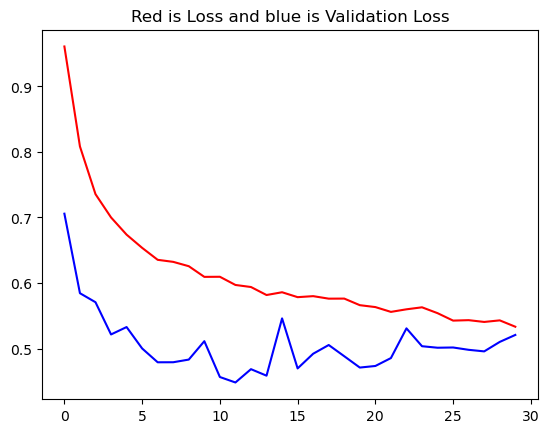

In [18]:
plt.plot(history.history['loss'], color='red')
plt.title("Red is Loss and blue is Validation Loss")
plt.plot(history.history['val_loss'], color='blue')

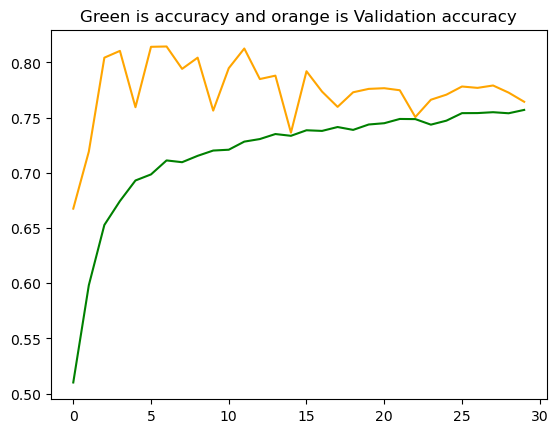

In [19]:
plt.plot(history.history['accuracy'], color='green', label='Train Data')
plt.title("Green is accuracy and orange is Validation accuracy")
plt.plot(history.history['val_accuracy'], color='orange', label='Validation Data')

In [54]:
model.save('FinalData.h5', 'wb')

c:\Users\moomad\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
nl = data.columns.to_list()

In [ ]:
import seaborn as sns
for i in data.columns.to_list():
    print(f'Plot for {i} at below' )
    sns.histplot(data[i])
    plt.show()